# Параллельные вычисления (1)

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Параллельные вычисления"
* https://docs.python.org/3/library/multiprocessing.html
    * https://docs.python.org/3/library/multiprocessing.html#multiprocessing.Process
    * https://docs.python.org/3/library/multiprocessing.html#multiprocessing.pool.Pool
    * https://docs.python.org/3/library/multiprocessing.html#multiprocessing.Queue
* https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
* https://numpy.org/doc/stable/reference/generated/numpy.array_split.html

## Задачи для совместного разбора

1. Посчитайте, сколько раз встречается буква "a" в файлах ["xaa", "xab", "xac", "xad"], используя пул процессов.

In [ ]:
import multiprocessing

files = [f"data/{name}.txt" for name in ["xaa", "xab", "xac", "xad"]]

In [ ]:
%%file count_a.py
def count_a(file):
    with open(file, "r", encoding="utf8") as fp:
        text = fp.read()
    r = text.count("a")
    return r

Overwriting count_a.py


In [ ]:
from count_a import count_a

In [ ]:
%%time
a = []
for file in files:
    a.append(count_a(file))
sum(a)

Wall time: 258 ms


8998272

In [ ]:
%%time
with multiprocessing.Pool(processes=4) as pool:
    r = pool.map(count_a, files)
sum(r)

Wall time: 255 ms


8998272

2. Посчитайте, сколько раз встречается буква "a" в файлах ["xaa", "xab", "xac", "xad"], используя процессы и очереди.

In [ ]:
%%file count_a_2.py
def count_a_2(file):
    with open(file, "r", encoding="utf8") as fp:
        text = fp.read()
    r = text.count("a")
    print(r)
    return r

Writing count_a_2.py


In [ ]:
from count_a_2 import count_a_2

In [ ]:
%%file count_a_3.py
def count_a_3(file, queue):
    with open(file, "r", encoding="utf8") as fp:
        text = fp.read()
    r = text.count("a")
    print(r)
    queue.put(r)

Overwriting count_a_3.py


In [ ]:
from count_a_3 import count_a_3

In [ ]:
%%time
processes = []
queue = multiprocessing.Queue()
for file in files:
    p = multiprocessing.Process(target=count_a_3, args=(file, queue))
    p.start()
    processes.append(p)
for p in processes:
    p.join()
# вот здесь мы уже уверены, что все процессы завершились
res = []
while len(res) < 4:
    if not queue.empty():
        r = queue.get()
        res.append(r)
    # ...
sum(res)

Wall time: 1.66 s


31606830

## Лабораторная работа 5

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy` и `pandas`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов `numpy` или структур `pandas` используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

<p class="task" id="1"></p>

1\. В каждой строке файла `tag_nsteps.csv` хранится информация о тэге рецепта и количестве шагов в этом рецепте в следующем виде:

```
tags,n_steps
hungarian,2
european,6
occasion,4
pumpkin,4
................
```

Всего в исходном файле хранится чуть меньше, чем 71 млн, строк. Разбейте файл `tag_nsteps.csv` на несколько (например, 8) примерно одинаковых по объему файлов c названиями `tag_nsteps_*.csv`, где вместо символа `*` указан номер очередного файла. Каждый файл имеет структуру, аналогичную оригинальному файлу (включая заголовок).

При создании файлов выводите на экран сообщения следующего вида:
`file: <название файла> #rows: <кол-во строк в этом файле>`

__Важно__: здесь и далее вы не можете загружать в память весь исходный файл сразу.

In [ ]:
import pandas as pd
import multiprocessing

In [ ]:
chunksize = 71_000_000//10
filename = r'data\tag_nsteps.csv'
for i, chunk in enumerate(pd.read_csv(filename, chunksize=chunksize)):
    chunk.to_csv(f'tag_nsteps_{i+1}.csv', index=False)
    print(f'file: tag_nsteps_{i+1}.csv #rows: {len(chunk)}')

file: tag_nsteps_1.csv #rows: 7100000
file: tag_nsteps_2.csv #rows: 7100000
file: tag_nsteps_3.csv #rows: 7100000
file: tag_nsteps_4.csv #rows: 7100000
file: tag_nsteps_5.csv #rows: 7100000
file: tag_nsteps_6.csv #rows: 7100000
file: tag_nsteps_7.csv #rows: 7100000
file: tag_nsteps_8.csv #rows: 7100000
file: tag_nsteps_9.csv #rows: 7100000
file: tag_nsteps_10.csv #rows: 6795585


<p class="task" id="2"></p>

2\. Напишите функцию, которая принимает на вход название файла, созданного в результате решения задачи 1, считает для каждого тэга сумму по столбцу `n_steps` и количество строк c этим тэгом, и возвращает результат в виде словаря. Ожидаемый вид итогового словаря:

```
{
    '1-day-or-more': {'sum': 56616, 'count': 12752},
    '15-minutes-or-less': {'sum': 195413, 'count': 38898},
    '3-steps-or-less': {'sum': 187938, 'count': 39711},
    ....
}
```

Примените данную функцию к каждому файлу, полученному в задании 1, и соберите результат в виде списка словарей. Не используйте параллельных вычислений.

Выведите на экран значение по ключу "30-minutes-or-less" для каждого из словарей.

In [ ]:
def get_tag_sum_count_from_file(file: str) -> dict:
    df_tags = pd.read_csv(file)
    tag_statistics = df_tags.groupby('tags')['n_steps'].agg(['sum', 'count']).to_dict('index')
    return tag_statistics

In [ ]:
lst_tag_sum_count = [get_tag_sum_count_from_file('tag_nsteps_1.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_2.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_3.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_4.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_5.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_6.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_7.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_8.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_9.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_10.csv')]

In [ ]:
for i in range (10):
    print (f'tag_nsteps_{i+1}.csv', lst_tag_sum_count[i]['30-minutes-or-less'])

tag_nsteps_1.csv {'sum': 279827, 'count': 36539}
tag_nsteps_2.csv {'sum': 277417, 'count': 36499}
tag_nsteps_3.csv {'sum': 284850, 'count': 37268}
tag_nsteps_4.csv {'sum': 278416, 'count': 36680}
tag_nsteps_5.csv {'sum': 279948, 'count': 36588}
tag_nsteps_6.csv {'sum': 276459, 'count': 36448}
tag_nsteps_7.csv {'sum': 279818, 'count': 36791}
tag_nsteps_8.csv {'sum': 279457, 'count': 36782}
tag_nsteps_9.csv {'sum': 278586, 'count': 36755}
tag_nsteps_10.csv {'sum': 268427, 'count': 35432}


<p class="task" id="3"></p>

3\. Напишите функцию, которая объединяет результаты обработки отдельных файлов. Данная функция принимает на вход список словарей, каждый из которых является результатом вызова функции `get_tag_sum_count_from_file` для конкретного файла, и агрегирует эти словари. Не используйте параллельных вычислений.

Процедура агрегации словарей имеет следующий вид:
$$d_{agg}[k] = \{sum: \sum_{i=1}^{n}d_{i}[k][sum], count: \sum_{i=1}^{n}d_{i}[k][count]\}$$
где $d_1, d_2, ..., d_n$- результат вызова функции `get_tag_sum_count_from_file` для конкретных файлов.

Примените данную функцию к результату выполнения задания 2. Выведите на экран результат для тэга "30-minutes-or-less".

In [ ]:
def agg_results(tag_sum_count_list: list) -> dict:
    dfs_from_lst = [pd.DataFrame(dct).T for dct in tag_sum_count_list]
    df_sc = pd.concat(dfs_from_lst, axis=0, ignore_index=False)
    agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')
    return agg_result

In [ ]:
tag_sum_count = agg_results(lst_tag_sum_count)
tag_sum_count['30-minutes-or-less']

C:\Users\timur\AppData\Local\Temp\ipykernel_8652\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


{'sum': 2783205, 'count': 365782}

<p class="task" id="4"></p>

4\. Напишите функцию, которая считает среднее значение количества шагов для каждого тэга в словаре. Используйте решения задач 1-3, чтобы получить среднее значение количества шагов каждого тэга для всего датасета, имея результаты обработки частей датасета и результат их агрегации. Выведите на экран результат для тэга "30-minutes-or-less".

Определите, за какое время задача решается для всего датасета. При замере времени учитывайте время расчета статистики для каждого файла, агрегации результатов и, собственно, вычисления средного. Временем, затрачиваемым на процедуру разбиения исходного файла, можно пренебречь.

In [ ]:
def get_tag_mean_n_steps(tag_sum_count: dict) -> dict:
    # tag_sum_count - результат вызова agg_results
    return (pd.DataFrame(tag_sum_count).T['sum']/pd.DataFrame(tag_sum_count).T['count']).to_dict()

In [ ]:
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

7.608917333275011

In [ ]:
%%time
lst_tag_sum_count = [get_tag_sum_count_from_file('tag_nsteps_1.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_2.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_3.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_4.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_5.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_6.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_7.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_8.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_9.csv'), \
                     get_tag_sum_count_from_file('tag_nsteps_10.csv')]
tag_sum_count = agg_results(lst_tag_sum_count)
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

Wall time: 28.4 s


C:\Users\timur\AppData\Local\Temp\ipykernel_8652\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


7.608917333275011

<p class="task" id="5"></p>

5\. Повторите решение задачи 4, распараллелив вызовы функции `get_tag_sum_count_from_file` для различных файлов с помощью `multiprocessing.Pool`. Для обработки каждого файла создайте свой собственный процесс. Выведите на экран результат для тэга "30-minutes-or-less". Определите, за какое время задача решается для всех файлов. При замере времени учитывайте время расчета статистики для каждого файла, агрегации результатов и, собственно, вычисления средного. Временем, затрачиваемым на процедуру разбиения исходного файла можно пренебречь.

In [ ]:
files = [f"tag_nsteps_{i+1}.csv" for i in range(10)]

In [ ]:
%%file get_tag_sum_count_from_file.py
import pandas as pd
def get_tag_sum_count_from_file(file: str) -> dict:
    df_tags = pd.read_csv(file)
    tag_statistics = df_tags.groupby('tags')['n_steps'].agg(['sum', 'count']).to_dict('index')
    return tag_statistics

Writing get_tag_sum_count_from_file.py


In [ ]:
from get_tag_sum_count_from_file import get_tag_sum_count_from_file

In [ ]:
%%time
with multiprocessing.Pool(processes=10) as pool:
    lst_tag_sum_count = pool.map(get_tag_sum_count_from_file, files)
tag_sum_count = agg_results(lst_tag_sum_count)
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

Wall time: 11.5 s


C:\Users\timur\AppData\Local\Temp\ipykernel_8652\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


7.608917333275011

<p class="task" id="6"></p>

6\. Повторите решение задачи 4, распараллелив вычисления функции `get_tag_sum_count_from_file` для различных файлов с помощью `multiprocessing.Process`. Для обработки каждого файла создайте свой собственный процесс. Для обмена данными между процессами используйте `multiprocessing.Queue`.

Выведите на экран результат для тэга "30-minutes-or-less". Определите, за какое время задача решается для всех файлов. При замере времени учитывайте время расчета статистики для каждого файла, агрегации результатов и, собственно, вычисления средного. Временем, затрачиваемым на процедуру разбиения исходного файла можно пренебречь.

In [ ]:
%%file get_tag_sum_count_from_file_1.py
import pandas as pd
def get_tag_sum_count_from_file_1(file, queue):
    df_tags = pd.read_csv(file)
    tag_statistics = df_tags.groupby('tags')['n_steps'].agg(['sum', 'count']).to_dict('index')
    print(tag_statistics)
    queue.put(tag_statistics)

Writing get_tag_sum_count_from_file_1.py


In [ ]:
from get_tag_sum_count_from_file_1 import get_tag_sum_count_from_file_1

In [ ]:
processes = []
queue = multiprocessing.Queue()

In [ ]:
%%time
for file in files:
    p = multiprocessing.Process(target=get_tag_sum_count_from_file_1, args=(file, queue))
    p.start()
    processes.append(p)
lst_tag_sum_count = []
for p in processes:
    if not queue.empty():
        r = queue.get()
        lst_tag_sum_count.append(r)

tag_sum_count = agg_results(lst_tag_sum_count)
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

Wall time: 355 ms


C:\Users\timur\AppData\Local\Temp\ipykernel_21380\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


7.608917333275011

<p class="task" id="7"></p>

7\. Исследуйте, как влияет количество запущенных одновременно процессов на скорость решения задачи. Узнайте количество ядер вашего процессора $K$ (воспользуйтесь функцией `multiprocessing.cpu_count`). Повторите решение задачи 1, разбив исходный файл на $\frac{K}{2}$, $K$ и $2K$ фрагментов. Для каждого из разбиений повторите решение задачи 5. Визуализируйте зависимость времени выполнения кода от количества файлов в разбиении. Сделайте вывод в виде текстового комментария.

In [ ]:
K = multiprocessing.cpu_count()
print(f"Количество ядер: {K}")

Количество ядер: 8


In [ ]:
# решение для K/2
chunksize = 71_000_000/(K/2)
filename = r'data\tag_nsteps.csv'
for i, chunk in enumerate(pd.read_csv(filename, chunksize=chunksize)):
    chunk.to_csv(f'tag_nsteps_{i+1}.csv', index=False)
    print(f'file: tag_nsteps_{i+1}.csv #rows: {len(chunk)}')

file: tag_nsteps_1.csv #rows: 17750000
file: tag_nsteps_2.csv #rows: 17750000
file: tag_nsteps_3.csv #rows: 17750000
file: tag_nsteps_4.csv #rows: 17445585


In [ ]:
files = [f"tag_nsteps_{i+1}.csv" for i in range(K//2)]

In [ ]:
%%time
with multiprocessing.Pool(processes=K//2) as pool:
    lst_tag_sum_count = pool.map(get_tag_sum_count_from_file, files)
tag_sum_count = agg_results(lst_tag_sum_count)
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

Wall time: 10.6 s


C:\Users\timur\AppData\Local\Temp\ipykernel_17248\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


7.608917333275011

In [ ]:
# решение для K
chunksize = 71_000_000/K
filename = r'data\tag_nsteps.csv'
for i, chunk in enumerate(pd.read_csv(filename, chunksize=chunksize)):
    chunk.to_csv(f'tag_nsteps_{i+1}.csv', index=False)
    print(f'file: tag_nsteps_{i+1}.csv #rows: {len(chunk)}')

file: tag_nsteps_1.csv #rows: 8875000
file: tag_nsteps_2.csv #rows: 8875000
file: tag_nsteps_3.csv #rows: 8875000
file: tag_nsteps_4.csv #rows: 8875000
file: tag_nsteps_5.csv #rows: 8875000
file: tag_nsteps_6.csv #rows: 8875000
file: tag_nsteps_7.csv #rows: 8875000
file: tag_nsteps_8.csv #rows: 8570585


In [ ]:
files = [f"tag_nsteps_{i+1}.csv" for i in range(K)]

In [ ]:
%%time
with multiprocessing.Pool(processes=K) as pool:
    lst_tag_sum_count = pool.map(get_tag_sum_count_from_file, files)
tag_sum_count = agg_results(lst_tag_sum_count)
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

Wall time: 10.2 s


C:\Users\timur\AppData\Local\Temp\ipykernel_17248\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


7.608917333275011

In [ ]:
# решение для 2K
chunksize = 71_000_000/(2*K)
filename = r'data\tag_nsteps.csv'
for i, chunk in enumerate(pd.read_csv(filename, chunksize=chunksize)):
    chunk.to_csv(f'tag_nsteps_{i+1}.csv', index=False)
    print(f'file: tag_nsteps_{i+1}.csv #rows: {len(chunk)}')

file: tag_nsteps_1.csv #rows: 4437500
file: tag_nsteps_2.csv #rows: 4437500
file: tag_nsteps_3.csv #rows: 4437500
file: tag_nsteps_4.csv #rows: 4437500
file: tag_nsteps_5.csv #rows: 4437500
file: tag_nsteps_6.csv #rows: 4437500
file: tag_nsteps_7.csv #rows: 4437500
file: tag_nsteps_8.csv #rows: 4437500
file: tag_nsteps_9.csv #rows: 4437500
file: tag_nsteps_10.csv #rows: 4437500
file: tag_nsteps_11.csv #rows: 4437500
file: tag_nsteps_12.csv #rows: 4437500
file: tag_nsteps_13.csv #rows: 4437500
file: tag_nsteps_14.csv #rows: 4437500
file: tag_nsteps_15.csv #rows: 4437500
file: tag_nsteps_16.csv #rows: 4133085


In [ ]:
files = [f"tag_nsteps_{i+1}.csv" for i in range(2*K)]

In [ ]:
%%time
with multiprocessing.Pool(processes=2*K) as pool:
    lst_tag_sum_count = pool.map(get_tag_sum_count_from_file, files)
tag_sum_count = agg_results(lst_tag_sum_count)
get_tag_mean_n_steps(tag_sum_count)['30-minutes-or-less']

Wall time: 12.8 s


C:\Users\timur\AppData\Local\Temp\ipykernel_17248\174902808.py:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  agg_result = df_sc.groupby(df_sc.index)['sum', 'count'].sum().to_dict('index')


7.608917333275011

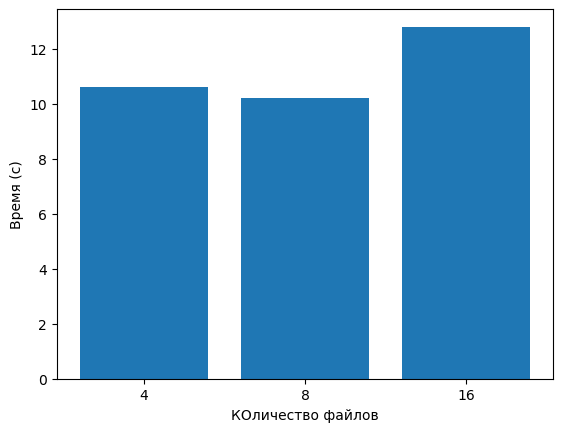

In [ ]:
import matplotlib.pyplot as plt

plt.bar(['4', '8', '16'], [10.6, 10.2, 12.8])
plt.xlabel("КОличество файлов")
plt.ylabel("Время (с)")
plt.show()


С увеличением количества процессов до количества ядер (8) производительность программы также увеличвается. Если количество процессов больше, чем количество ядер процессора, то время выполнения задачи увеличится из-за увеличения накладных расходов на синхронизацию между процессами